# Replication lab: Chain-of-Thought Prompting Elicits Reasoning in Large Language Models

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/webpug/aiML/blob/main/research-notebooks/01-chain-of-thought-prompting.ipynb)

**Paper:** Jason Wei, Xuezhi Wang, Dale Schuurmans, Maarten Bosma, Brian Ichter, Fei Xia, Ed H. Chi, Quoc V. Le, and Denny Zhou (Google Research, Brain Team), NeurIPS 2022.  
**Read:** [arXiv:2201.11903](https://arxiv.org/abs/2201.11903) · [PDF](https://arxiv.org/pdf/2201.11903)

> **What this is.** A runnable replication of the paper's *experimental method* on GSM8K using an openly available instruction-tuned model. Exact reproduction is impossible: the LaMDA, PaLM, and GPT-3 checkpoints and original inference infrastructure are unavailable. Model family, instruction tuning, chat formatting, hardware, and sample size all differ. We will therefore test the same intervention—standard few-shot versus rationale-bearing few-shot prompts—without claiming to reproduce the paper's numbers.

## Complete abstract (verbatim)

> We explore how generating a chain of thought—a series of intermediate reasoning steps—significantly improves the ability of large language models to perform complex reasoning. In particular, we show how such reasoning abilities emerge naturally in sufficiently large language models via a simple method called chain-of-thought prompting, where a few chain of thought demonstrations are provided as exemplars in prompting. Experiments on three large language models show that chain-of-thought prompting improves performance on a range of arithmetic, commonsense, and symbolic reasoning tasks. The empirical gains can be striking. For instance, prompting a PaLM 540B with just eight chain-of-thought exemplars achieves state-of-the-art accuracy on the GSM8K benchmark of math word problems, surpassing even finetuned GPT-3 with a verifier.


## Lab map and hypotheses

`setup → hypotheses → preregistration → data → visible prompts → batched inference → evaluation → ablations → errors → paper comparison`

This lab prioritizes measurement. Nothing below contains simulated or hard-coded model accuracy. Result tables and figures exist only after generation.

**Primary hypothesis (written before results):** on this frozen GSM8K sample, few-shot CoT will have higher exact-match accuracy than direct few-shot prompting.  
**Cost hypothesis:** CoT will generate more tokens and take longer.  
**Ablation hypothesis:** meaningful ordered decomposition will outperform length-like meaningless filler; equation-only behavior may sit between direct and full CoT.  
**Falsifiers:** a non-positive paired accuracy difference falsifies the primary directional hypothesis on this sample; similar token counts/latencies falsify the cost hypothesis.

Accuracy on a small sample is noisy, so we report paired bootstrap uncertainty and retain every output for inspection. Generated rationales are observable text, not guaranteed faithful access to internal computation.


In [1]:
# Preregistration-style configuration: edit this cell BEFORE looking at results.
from dataclasses import dataclass, asdict
from pathlib import Path
import json, os, random, re, time, hashlib, platform

@dataclass(frozen=True)
class Config:
    model_id: str = "Qwen/Qwen2.5-3B-Instruct"
    model_revision: str = "main"       # resolve/capture the exact commit below
    dataset_id: str = "openai/gsm8k"
    dataset_config: str = "main"
    seed: int = 22011903
    n_test: int = 24                    # 24 is a useful small lab; increase only before results
    n_boot: int = 5000
    batch_size: int = 4                 # reduce to 2 if Colab is memory-constrained
    max_new_tokens: int = 192           # identical cap across prompt conditions
    checkpoint_dir: str = "/content/cot-replication"
    run_experiment: bool = True
    allow_cpu_smoke: bool = False       # optional only; the 3B experiment is intended for a T4
    smoke_test: bool = False            # uses 2 test cases, 2 conditions, 48 output tokens

CFG = Config()
print(json.dumps(asdict(CFG), indent=2))
print("Freeze this cell before generating. Changing it creates a new run fingerprint.")


{
  "model_id": "Qwen/Qwen2.5-3B-Instruct",
  "model_revision": "main",
  "dataset_id": "openai/gsm8k",
  "dataset_config": "main",
  "seed": 22011903,
  "n_test": 24,
  "n_boot": 5000,
  "batch_size": 4,
  "max_new_tokens": 192,
  "checkpoint_dir": "/content/cot-replication",
  "run_experiment": true,
  "allow_cpu_smoke": false,
  "smoke_test": false
}
Freeze this cell before generating. Changing it creates a new run fingerprint.


### Colab setup and deliberate stop guard

In Colab choose **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**. The default 3B model is ungated and needs no token or paid API. Its bfloat16 weights are roughly 6 GB; runtime memory is higher because prompts, activations, CUDA kernels, and the key/value (KV) cache also occupy VRAM.

The next cell intentionally stops early with one useful error when the GPU is absent. That prevents later download/inference cells from cascading. For a tiny plumbing check only, set `allow_cpu_smoke=True`, `smoke_test=True`, and use a genuinely tiny compatible model; CPU results are not the registered experiment.


In [2]:
import subprocess, sys
try:
    import torch
except ImportError:
    torch = None

has_gpu = bool(torch and torch.cuda.is_available())
if CFG.run_experiment and not has_gpu and not CFG.allow_cpu_smoke:
    raise RuntimeError(
        "GPU not detected. In Colab select Runtime → Change runtime type → T4 GPU, "
        "then run all again. No model/data download has started."
    )

print("Python:", platform.python_version())
print("Accelerator:", torch.cuda.get_device_name(0) if has_gpu else "CPU smoke mode")
if has_gpu:
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory: {free/2**30:.1f} GiB free / {total/2**30:.1f} GiB total")
    subprocess.run(["nvidia-smi", "--query-gpu=name,memory.used,memory.total,utilization.gpu", "--format=csv"], check=False)


Python: 3.12.13
Accelerator: Tesla T4
GPU memory: 14.5 GiB free / 14.6 GiB total


In [3]:
# Install pinned-compatible versions after the runtime guard. Colab may ship older packages,
# so checking only whether a module exists is not sufficient.
import subprocess, sys
requirements = ["transformers>=4.45,<5", "datasets>=2.19,<5", "accelerate>=0.30,<2",
                "pandas>=2,<3", "matplotlib>=3.7,<4", "seaborn>=0.13,<1"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *requirements])
print("Dependencies ready. If Colab asks for a runtime restart, restart and run all once more.")


Dependencies ready. If Colab asks for a runtime restart, restart and run all once more.


## Data: a frozen, deterministic GSM8K sample

We draw exemplars from the training split and evaluation cases from the test split. Sampling uses a local seeded RNG and sorted indices, so condition order does not alter the questions. GSM8K gold solutions end in `#### number`; the parser tests below exercise commas, signs, decimals, and fractions. Smoke mode is for checking plumbing, not inference claims.


In [4]:
from fractions import Fraction
from decimal import Decimal, InvalidOperation

FINAL_PATTERNS = [
    re.compile(r"(?i)(?:final answer|answer is|answer)\s*[:=]?\s*\$?\s*(-?[\d,]+(?:\.\d+)?(?:/\d+)?)"),
    re.compile(r"####\s*\$?\s*(-?[\d,]+(?:\.\d+)?(?:/\d+)?)"),
]
NUMBER_RE = re.compile(r"-?[\d,]+(?:\.\d+)?(?:/\d+)?")

def normalize_number(raw):
    if raw is None: return None
    s = str(raw).strip().replace(",", "").replace("$", "")
    try:
        if "/" in s:
            value = Fraction(s)
            return str(value.numerator) if value.denominator == 1 else f"{value.numerator}/{value.denominator}"
        d = Decimal(s)
        if not d.is_finite(): return None
        return format(d.normalize(), "f")
    except (ValueError, ZeroDivisionError, InvalidOperation):
        return None

def parse_final_answer(text):
    for pattern in FINAL_PATTERNS:
        hits = pattern.findall(text or "")
        if hits: return normalize_number(hits[-1])
    hits = NUMBER_RE.findall(text or "")
    return normalize_number(hits[-1]) if hits else None

tests = {"The answer is 1,234.":"1234", "Final answer: -2.50":"-2.5", "work 1/2; answer = 3/2":"3/2",
         "no numeric answer":None, "x=2 then 7":"7", "#### 6.0":"6"}
for text, expected in tests.items():
    assert parse_final_answer(text) == expected, (text, parse_final_answer(text), expected)
print("Parser utility tests passed:", len(tests))


Parser utility tests passed: 6


In [5]:
from datasets import load_dataset
ds = load_dataset(CFG.dataset_id, CFG.dataset_config)
rng = random.Random(CFG.seed)
n = 2 if CFG.smoke_test else CFG.n_test
test_indices = sorted(rng.sample(range(len(ds["test"])), n))
test_rows = [dict(ds["test"][i], example_id=f"test-{i}") for i in test_indices]
print(f"Loaded {len(ds['train'])} train / {len(ds['test'])} test; selected indices:", test_indices)
print("First selected question:", test_rows[0]["question"])
print("Gold:", parse_final_answer(test_rows[0]["answer"]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 7473 train / 1319 test; selected indices: [5, 152, 162, 244, 297, 316, 390, 447, 512, 546, 557, 609, 731, 752, 757, 772, 861, 881, 924, 942, 1022, 1091, 1092, 1167]
First selected question: Kylar went to the store to buy glasses for his new apartment. One glass costs $5, but every second glass costs only 60% of the price. Kylar wants to buy 16 glasses. How much does he need to pay for them?
Gold: 64


## Prompt intervention: same questions, different demonstrated outputs

The four manually written exemplar questions are held constant. Only the answer style changes. This is fewer than the paper's eight arithmetic exemplars to fit a modest open model's context and a short Colab session—a declared departure from the original protocol.

- `direct`: answer only (standard few-shot baseline)
- `cot`: natural-language steps before the answer
- `equation`: equations plus answer, inspired by the paper's equation-only ablation
- `concise`: short semantic decomposition plus answer (an added modern ablation)
- `filler`: meaningless dot tokens before the answer, approximately matched to each CoT exemplar's whitespace-token length

The filler match is approximate after subword tokenization, and our instruction-tuned chat model may ignore it. This is paper-inspired, not an exact reconstruction of the paper's variable-compute protocol.


In [6]:
EXEMPLARS = [
 {"q":"Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 balls. How many balls does he have now?", "a":"11",
  "cot":"Two cans contain 2 × 3 = 6 balls. Adding the 5 original balls gives 5 + 6 = 11. The answer is 11.",
  "equation":"2 × 3 = 6; 5 + 6 = 11. The answer is 11.", "concise":"Find balls bought, then add the starting amount: 6 + 5 = 11. The answer is 11."},
 {"q":"A cafeteria had 23 apples. It used 20 for lunch and bought 6 more. How many apples does it have?", "a":"9",
  "cot":"After using 20 apples, 23 - 20 = 3 remain. Buying 6 more gives 3 + 6 = 9. The answer is 9.",
  "equation":"23 - 20 = 3; 3 + 6 = 9. The answer is 9.", "concise":"Subtract those used, then add those bought: 23 - 20 + 6 = 9. The answer is 9."},
 {"q":"There are 15 trees in a grove. Workers plant 3 rows of 4 trees. How many trees are there now?", "a":"27",
  "cot":"The workers plant 3 × 4 = 12 trees. Adding them to the original 15 gives 15 + 12 = 27. The answer is 27.",
  "equation":"3 × 4 = 12; 15 + 12 = 27. The answer is 27.", "concise":"Compute the newly planted trees, then add: 12 + 15 = 27. The answer is 27."},
 {"q":"Mia has 40 stickers and gives one quarter of them away. How many stickers remain?", "a":"30",
  "cot":"One quarter of 40 is 40 ÷ 4 = 10 stickers. Mia keeps 40 - 10 = 30 stickers. The answer is 30.",
  "equation":"40 ÷ 4 = 10; 40 - 10 = 30. The answer is 30.", "concise":"Find the quarter given away and subtract it: 40 - 10 = 30. The answer is 30."},
]
CONDITIONS = ["direct", "cot", "equation", "concise", "filler"]
if CFG.smoke_test: CONDITIONS = ["direct", "cot"]

def exemplar_answer(ex, condition):
    if condition == "direct": return f"The answer is {ex['a']}."
    if condition in {"cot", "equation", "concise"}: return ex[condition]
    n = max(1, len(ex["cot"].split()) - len(f"The answer is {ex['a']}.".split()))
    return " ".join(["..."] * n) + f" The answer is {ex['a']}."

def build_user_prompt(question, condition):
    blocks = ["Solve the math word problems. Follow the demonstrated answer style exactly."]
    for ex in EXEMPLARS:
        blocks.append(f"Question: {ex['q']}\nAnswer: {exemplar_answer(ex, condition)}")
    blocks.append(f"Question: {question}\nAnswer:")
    return "\n\n".join(blocks)

for condition in CONDITIONS:
    print("\n" + "="*22, condition.upper(), "="*22)
    print(build_user_prompt("A notebook costs $4. What do 3 notebooks cost?", condition))



====================== DIRECT ======================
Solve the math word problems. Follow the demonstrated answer style exactly.

Question: Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 balls. How many balls does he have now?
Answer: The answer is 11.

Question: A cafeteria had 23 apples. It used 20 for lunch and bought 6 more. How many apples does it have?
Answer: The answer is 9.

Question: There are 15 trees in a grove. Workers plant 3 rows of 4 trees. How many trees are there now?
Answer: The answer is 27.

Question: Mia has 40 stickers and gives one quarter of them away. How many stickers remain?
Answer: The answer is 30.

Question: A notebook costs $4. What do 3 notebooks cost?
Answer:

====================== COT ======================
Solve the math word problems. Follow the demonstrated answer style exactly.

Question: Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 balls. How many balls does he have now?
Answer: Two cans con

## Model loading and infrastructure

Transformers first formats a system/user conversation with the tokenizer's chat template. The entire prompt is processed in parallel during **prefill**. The model then **decodes autoregressively**, one new token per sequence at each step. The KV cache avoids recomputing attention keys/values for old tokens, trading VRAM for speed. Batching shares GPU work, but a batch waits for its longest sequence and its aggregate KV cache must fit. Longer CoT therefore adds decode iterations, KV-cache growth, latency, and energy even when accuracy does not improve.

Qwen2.5-3B-Instruct is ungated, stable, and comfortable in bfloat16 on a free T4. We use greedy decoding (`do_sample=False`) and record the resolved Hub commit, library versions, prompts, and config. T4 supports fp16 well; this cell chooses bf16 only where the device reports support.


In [7]:
import transformers, datasets, pandas as pd, numpy as np
from huggingface_hub import model_info
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(CFG.seed); random.seed(CFG.seed); np.random.seed(CFG.seed)
if has_gpu: torch.cuda.manual_seed_all(CFG.seed)
resolved_revision = model_info(CFG.model_id, revision=CFG.model_revision).sha
dtype = torch.bfloat16 if has_gpu and torch.cuda.is_bf16_supported() else (torch.float16 if has_gpu else torch.float32)
tokenizer = AutoTokenizer.from_pretrained(CFG.model_id, revision=resolved_revision)
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None: tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    CFG.model_id, revision=resolved_revision, torch_dtype=dtype,
    device_map="auto" if has_gpu else None, low_cpu_mem_usage=True
).eval()
device = next(model.parameters()).device
capture = {"config":asdict(CFG), "resolved_model_revision":resolved_revision,
           "transformers":transformers.__version__, "datasets":datasets.__version__,
           "torch":torch.__version__, "device":str(device), "gpu":torch.cuda.get_device_name(0) if has_gpu else None}
print(json.dumps(capture, indent=2))


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

{
  "config": {
    "model_id": "Qwen/Qwen2.5-3B-Instruct",
    "model_revision": "main",
    "dataset_id": "openai/gsm8k",
    "dataset_config": "main",
    "seed": 22011903,
    "n_test": 24,
    "n_boot": 5000,
    "batch_size": 4,
    "max_new_tokens": 192,
    "checkpoint_dir": "/content/cot-replication",
    "run_experiment": true,
    "allow_cpu_smoke": false,
    "smoke_test": false
  },
  "resolved_model_revision": "aa8e72537993ba99e69dfaafa59ed015b17504d1",
  "transformers": "4.57.6",
  "datasets": "4.8.5",
  "torch": "2.11.0+cu128",
  "device": "cuda:0",
  "gpu": "Tesla T4"
}


In [8]:
def format_chat(user_text):
    messages = [
        {"role":"system", "content":"You are a careful math solver. End every response with 'The answer is NUMBER'."},
        {"role":"user", "content":user_text},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

preview = format_chat(build_user_prompt(test_rows[0]["question"], "cot"))
print(preview[:5000])
print("Prompt tokens:", len(tokenizer(preview, add_special_tokens=False).input_ids))


<|im_start|>system
You are a careful math solver. End every response with 'The answer is NUMBER'.<|im_end|>
<|im_start|>user
Solve the math word problems. Follow the demonstrated answer style exactly.

Question: Roger has 5 tennis balls. He buys 2 cans of tennis balls. Each can has 3 balls. How many balls does he have now?
Answer: Two cans contain 2 × 3 = 6 balls. Adding the 5 original balls gives 5 + 6 = 11. The answer is 11.

Question: A cafeteria had 23 apples. It used 20 for lunch and bought 6 more. How many apples does it have?
Answer: After using 20 apples, 23 - 20 = 3 remain. Buying 6 more gives 3 + 6 = 9. The answer is 9.

Question: There are 15 trees in a grove. Workers plant 3 rows of 4 trees. How many trees are there now?
Answer: The workers plant 3 × 4 = 12 trees. Adding them to the original 15 gives 15 + 12 = 27. The answer is 27.

Question: Mia has 40 stickers and gives one quarter of them away. How many stickers remain?
Answer: One quarter of 40 is 40 ÷ 4 = 10 stickers. 

## Batched, checkpointed generation

Each completed row is appended immediately to JSONL. Rerunning skips matching keys, so a disconnect loses at most the active batch. The fingerprint includes the full configuration, resolved model revision, test indices, and exemplar text. The default path is ephemeral Colab storage. To persist it, opt in by mounting Drive yourself and change `checkpoint_dir` to a Drive path—this notebook never mounts or accesses Drive automatically.


In [9]:
run_payload = {"capture":capture, "test_indices":test_indices, "exemplars":EXEMPLARS, "conditions":CONDITIONS}
run_id = hashlib.sha256(json.dumps(run_payload, sort_keys=True).encode()).hexdigest()[:12]
run_dir = Path(CFG.checkpoint_dir) / run_id
run_dir.mkdir(parents=True, exist_ok=True)
(run_dir / "manifest.json").write_text(json.dumps(run_payload, indent=2))
jsonl_path = run_dir / "generations.jsonl"

def load_completed(path):
    rows = []
    if path.exists():
        for line in path.read_text().splitlines():
            try: rows.append(json.loads(line))
            except json.JSONDecodeError: print("Ignoring incomplete checkpoint line")
    return rows

def generate_batch(items, condition):
    texts = [format_chat(build_user_prompt(x["question"], condition)) for x in items]
    batch = tokenizer(texts, return_tensors="pt", padding=True, add_special_tokens=False).to(device)
    prompt_width = batch["input_ids"].shape[1]
    if has_gpu:
        torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.inference_mode():
        output = model.generate(**batch, do_sample=False,
            max_new_tokens=(48 if CFG.smoke_test else CFG.max_new_tokens),
            pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id,
            use_cache=True)
    if has_gpu: torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    generated = output[:, prompt_width:]
    peak = torch.cuda.max_memory_allocated()/2**30 if has_gpu else None
    rows = []
    for item, ids in zip(items, generated):
        ids = ids[ids != tokenizer.pad_token_id]
        text = tokenizer.decode(ids, skip_special_tokens=True).strip()
        gold = parse_final_answer(item["answer"]); pred = parse_final_answer(text)
        rows.append({"run_id":run_id, "example_id":item["example_id"], "condition":condition,
                     "question":item["question"], "gold":gold, "prediction":pred, "correct":pred==gold,
                     "output":text, "generated_tokens":int(len(ids)),
                     "batch_latency_s":elapsed, "latency_s_per_example":elapsed/len(items),
                     "peak_allocated_gib":peak, "timestamp_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())})
    return rows

completed = load_completed(jsonl_path)
done = {(r["condition"], r["example_id"]) for r in completed}
for condition in CONDITIONS:
    pending = [r for r in test_rows if (condition, r["example_id"]) not in done]
    for start_i in range(0, len(pending), CFG.batch_size):
        new_rows = generate_batch(pending[start_i:start_i+CFG.batch_size], condition)
        with jsonl_path.open("a") as f:
            for row in new_rows: f.write(json.dumps(row) + "\n")
        completed.extend(new_rows)
        print(condition, f"{min(start_i+len(new_rows), len(pending))}/{len(pending)} new", "saved")
print("Checkpoint:", jsonl_path)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


direct 4/24 new saved
direct 8/24 new saved
direct 12/24 new saved
direct 16/24 new saved
direct 20/24 new saved
direct 24/24 new saved
cot 4/24 new saved
cot 8/24 new saved
cot 12/24 new saved
cot 16/24 new saved
cot 20/24 new saved
cot 24/24 new saved
equation 4/24 new saved
equation 8/24 new saved
equation 12/24 new saved
equation 16/24 new saved
equation 20/24 new saved
equation 24/24 new saved
concise 4/24 new saved
concise 8/24 new saved
concise 12/24 new saved
concise 16/24 new saved
concise 20/24 new saved
concise 24/24 new saved
filler 4/24 new saved
filler 8/24 new saved
filler 12/24 new saved
filler 16/24 new saved
filler 20/24 new saved
filler 24/24 new saved
Checkpoint: /content/cot-replication/2947ade5108c/generations.jsonl


## Evaluation with paired uncertainty

Exact match compares normalized final numbers. It does not grade rationale validity. The bootstrap resamples *examples* with replacement while keeping all conditions paired. Percentile intervals describe sampling uncertainty for this frozen empirical distribution; with a small sample they will be wide and should not be treated as population guarantees.


In [10]:
results = pd.DataFrame(load_completed(jsonl_path))
assert not results.duplicated(["condition","example_id"]).any()
assert set(results.groupby("condition").size()) == {len(test_rows)}, "Incomplete condition; resume generation first"
results.to_csv(run_dir / "generations.csv", index=False)

def bootstrap_summary(frame, n_boot=CFG.n_boot, seed=CFG.seed):
    pivot = frame.pivot(index="example_id", columns="condition", values="correct").astype(float)
    arr = pivot.to_numpy(); rng = np.random.default_rng(seed)
    draws = arr[rng.integers(0, len(arr), size=(n_boot, len(arr)))].mean(axis=1)
    out = []
    for j, name in enumerate(pivot.columns):
        lo, hi = np.quantile(draws[:,j], [.025,.975])
        out.append({"condition":name, "accuracy":arr[:,j].mean(), "ci_low":lo, "ci_high":hi})
    return pd.DataFrame(out), pivot, draws

accuracy, paired, draws = bootstrap_summary(results)
display(accuracy.sort_values("accuracy", ascending=False).style.format({"accuracy":"{:.1%}","ci_low":"{:.1%}","ci_high":"{:.1%}"}))
if {"direct","cot"} <= set(paired.columns):
    diff = draws[:,list(paired.columns).index("cot")] - draws[:,list(paired.columns).index("direct")]
    print(f"Paired CoT − direct: {paired.cot.mean()-paired.direct.mean():+.1%}; 95% bootstrap interval [{np.quantile(diff,.025):+.1%}, {np.quantile(diff,.975):+.1%}]")


,condition,accuracy,ci_low,ci_high
1,cot,75.0%,58.3%,91.7%
0,concise,70.8%,54.2%,87.5%
3,equation,70.8%,54.1%,87.5%
4,filler,58.3%,37.5%,75.0%
2,direct,12.5%,0.0%,25.0%


Paired CoT − direct: +62.5%; 95% bootstrap interval [+41.7%, +79.2%]


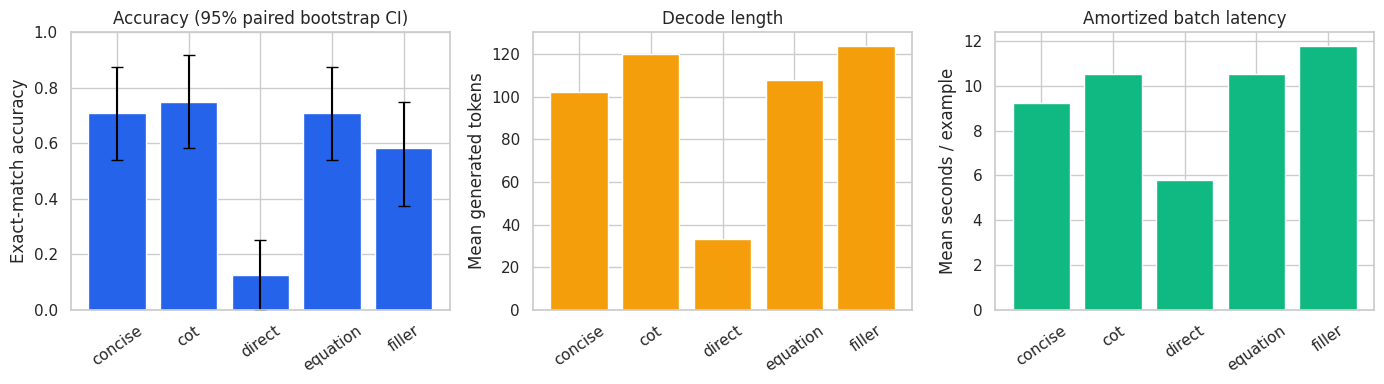

,max observed peak allocated GiB
condition,
concise,5.973143
cot,6.010827
direct,5.910085
equation,5.973143
filler,5.967577


In [11]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
agg = results.groupby("condition", as_index=False).agg(tokens=("generated_tokens","mean"), latency=("latency_s_per_example","mean"))
plot = accuracy.merge(agg)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(plot.condition, plot.accuracy, color="#2563eb")
axes[0].errorbar(range(len(plot)), plot.accuracy, yerr=[plot.accuracy-plot.ci_low, plot.ci_high-plot.accuracy], fmt="none", color="black", capsize=4)
axes[0].set(ylabel="Exact-match accuracy", ylim=(0,1), title="Accuracy (95% paired bootstrap CI)")
axes[1].bar(plot.condition, plot.tokens, color="#f59e0b"); axes[1].set(ylabel="Mean generated tokens", title="Decode length")
axes[2].bar(plot.condition, plot.latency, color="#10b981"); axes[2].set(ylabel="Mean seconds / example", title="Amortized batch latency")
for ax in axes: ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()
display(results.groupby("condition")[["peak_allocated_gib"]].max().rename(columns={"peak_allocated_gib":"max observed peak allocated GiB"}))


## Side-by-side outputs and error inspection

The automated categories are deliberately modest: parse failure, wrong answer with equation-like text, wrong answer without it, or correct. They help triage; they do **not** establish whether a rationale is logically valid or causally faithful. Read a blinded sample and add a `manual_error` column (for example: arithmetic slip, wrong operation, missing step, semantic misunderstanding, malformed final answer).


In [12]:
side = results.pivot(index=["example_id","question","gold"], columns="condition", values=["prediction","output"])
pd.set_option("display.max_colwidth", 120)
display(side.reset_index())

def error_category(row):
    if row.correct: return "correct"
    if row.prediction is None: return "parse failure"
    if re.search(r"\d\s*[-+×*/=÷]\s*\d", row.output): return "wrong — equation present"
    return "wrong — no equation detected"
results["error_category"] = results.apply(error_category, axis=1)
display(pd.crosstab(results.condition, results.error_category))
display(results.loc[~results.correct, ["condition","question","gold","prediction","output","error_category"]].sort_values(["condition","example_id"]))


example_id  \
condition              
0          test-1022   
1          test-1091   
2          test-1092   
3          test-1167   
4           test-152   
5           test-162   
6           test-244   
7           test-297   
8           test-316   
9           test-390   
10          test-447   
11            test-5   
12          test-512   
13          test-546   
14          test-557   
15          test-609   
16          test-731   
17          test-752   
18          test-757   
19          test-772   
20          test-861   
21          test-881   
22          test-924   
23          test-942   

                                                                                                                          question  \
condition                                                                                                                            
0          Teresa sells large stuffed animals for three times the price of small stuffed animals. Today, she sold twice as many...   
1          An apple orchard sells apples in bags of 10. The orchard sold a total of 2000 apples one day. How much did an orchar...   
2          A Tyrannosaurus rex ate half of a small triceratops it had hunted. When it left, a pack of velociraptors scavenged h...   
3                                             Jack had $100. Sophia gave him 1/5 of her $100. How many dollars does Jack have now?   
4          Carl buys ten packs of cookies. Each pack of cookies has six cookies inside. Each cookie cost $0.10. How much change...   
5          If a bag of marbles costs $20 and the price increases by 20% of the original price every two months, how much would ...   
6          Griffin had 24 french fries, but Kyle took 5 of them.  Billy took twice as many as Kyle.  Ginger gave Griffin a hand...   
7          Sam sells bread. He has a target of selling 120 crates of bread in a week. One week he was closed on Monday and Frid...   
8          Solomon bought 20 marbles from his friend Johanna and added them to a store that had 50. If his father also gave him...   
9          Monica is wrapping Christmas gifts. She has 6 gifts to wrap for her family, 4 gifts to wrap for her friends and 2 gi...   
10         Joey has 214 points before his turn in Scrabble. He scores 26 points. Then Marcy, who has 225 points, scores 10 poin...   
11         Kylar went to the store to buy glasses for his new apartment. One glass costs $5, but every second glass costs only ...   
12         Hannah needs to drink 60 ml of water for each kilometer she runs. If her gym teacher tells her to run 8 laps and eac...   
13         Elise is learning to write and decides to keep re-writing the alphabet until she knows it. She writes it in full twi...   
14         A bag of buttons had 21 buttons in it. Seven buttons had two holes and the rest had four holes. How many holes were ...   
15         Juan wants to add croissants to his bakery menu.  It takes 1/4 pound of butter to make 1 dozen croissants.  He wants...   
16         Each sleeve of graham crackers makes the base for 8 large smores.  There are 3 sleeves in a box.  If 9 kids want 2 s...   
17         Jenna has 4 roommates. Each month the electricity bill is $100. How much will each roommate pay per year for electri...   
18         Krissa needs to order field trip shirts for her preschool students. 11 students need size extra-small.  Twice as man...   
19         Tatiana is deciding how much of her weekend she wants to spend playing soccer. She has 7 hours on Saturday and 5 hou...   
20         Claire earns 1 girl scout badge every month.  It takes Amber twice as long to earn a badge than Claire.  Wendy earns...   
21                            In 10 years, Melanie will be 18 years old. In how many years will her age be thrice her present age?   
22         A three-toed sloth moves very slowly, and only eats when he is up in his tree.  For a meal of berries, it takes the ...   
23         Patty's Plumbing charges

error_category,correct,parse failure,wrong — equation present,wrong — no equation detected
condition,,,,
concise,17,0,6,1
cot,18,1,4,1
direct,3,1,1,19
equation,17,1,5,1
filler,14,3,2,5


KeyError: 'example_id'

In [ ]:
# Optional learner annotation: edit values, then persist without touching raw JSONL.
review = results[["example_id","condition","question","gold","prediction","output","error_category"]].copy()
review["manual_error"] = ""  # e.g. arithmetic / operation / missing step / semantic / formatting
review_path = run_dir / "manual_error_review.csv"
review.to_csv(review_path, index=False)
print("Editable review sheet:", review_path)


## Optional scale probe (a separate, confounded experiment)

Compare `Qwen/Qwen2.5-1.5B-Instruct` and `Qwen/Qwen2.5-3B-Instruct` by rerunning the notebook with each `model_id` and the same frozen indices. Both are genuinely runnable on a T4; run them sequentially and save each fingerprinted directory. Before loading the second model, delete the first model/tokenizer and call `torch.cuda.empty_cache()`.

**Do not interpret a difference as a clean parameter-scaling law.** Even within one named family, checkpoint training, capacity, optimization, chat behavior, prompt sensitivity, and quantization/dtype interactions are entangled; across architectures they are more so. Two sizes and 24 items cannot reproduce the paper's scale curves. A 7B option may fit with 4-bit quantization, but quantization adds another confound and extra dependencies, so it is intentionally not the default.


In [ ]:
# Run only between model runs—not during the active experiment.
def release_model():
    global model, tokenizer
    del model, tokenizer
    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("Model released. Change CFG.model_id and rerun from model loading.")
# release_model()  # intentionally opt-in


## Inspect the machine while it works

Run `watch -n 1 nvidia-smi` in a Colab terminal during generation, or execute the snapshot cell between batches. `memory.used` includes more than tensors reported by PyTorch. GPU utilization can look bursty because tokenization, Python, checkpoint writes, and autoregressive synchronization happen around GPU kernels.


In [ ]:
if has_gpu:
    subprocess.run(["nvidia-smi", "--query-gpu=timestamp,name,memory.used,memory.total,utilization.gpu,power.draw", "--format=csv"], check=False)
    print("PyTorch allocated GiB:", round(torch.cuda.memory_allocated()/2**30, 3))
    print("PyTorch reserved GiB:", round(torch.cuda.memory_reserved()/2**30, 3))


## Compare only after running

Now compare your measured direction—not raw accuracy—to Wei et al. The paper used eight hand-written CoT exemplars and greedy decoding. Its historical headline on GSM8K was **57% for PaLM 540B with CoT versus 18% with standard prompting**. It also reported that equation-only helped less on semantically difficult GSM8K, length-matched meaningless tokens were around baseline, and gains became much larger at sufficient model scale.

Your run is expected to differ because Qwen2.5 is a much smaller, newer, instruction-tuned open model; the exemplar set and chat wrapper differ; the evaluation sample is tiny; and modern training may include math-oriented data. Report discrepancies rather than explaining them away.

Reflection:

1. Did the paired interval exclude zero, or is the sample inconclusive?
2. Which condition changed answer accuracy per extra generated token most favorably?
3. Did the model obey the filler format? If not, what intervention did the ablation actually test?
4. Were parse failures evaluation bugs, instruction-following failures, or both?
5. Which wrong rationales were locally plausible but semantically wrong?
6. What would you freeze before increasing `n_test`?

### Lab limits

Exact-match misses no-value distinctions and ignores rationale validity. Latency is hardware- and batch-dependent. Bootstrap intervals do not account for prompt selection, model selection, benchmark contamination, or hyperparameter search. CoT text can be persuasive and still wrong or unfaithful. For consequential systems, prefer concise auditable intermediate representations, external calculation, and independent verification.


## Reproducibility handoff

Keep the run directory containing `manifest.json`, append-only `generations.jsonl`, `generations.csv`, and the optional manual review. Record the Colab GPU type and notebook commit alongside it. The manifest captures the resolved model commit, package versions, seed, sampled indices, prompts, and generation cap.

No secret, gated checkpoint, API key, or paid service is used. The only network operations are public Hugging Face package/model/dataset downloads.
